# Climate Change Signal — DestinE Generation 2

Compare **30-year mean 2m temperature between historical and scenario experiments** across IFS-FESOM, IFS-NEMO, and ICON using monthly (`clmn`) data from the DestinE Climate DT Generation 2 simulations.

In [ ]:
from destine_climate_helpers import fetch_period
from destine_portfolio import _MODEL_ENDYEAR_RELEASE
import healpy as hp
import matplotlib.pyplot as plt

In [ ]:
# --- Configuration ---
PARAM = 'avg_2t'
PARAM_NAME = '2m temperature'
MODELS = ['IFS-NEMO', 'IFS-FESOM', 'ICON']
RESOLUTION = 'standard'
STORE_DATA = True          # Set True to cache NetCDF files to DATA_DIR
DATA_DIR = './data'

# Historical period
HIST_YEARS = range(2000, 2015)
HIST_EXPERIMENT = 'hist'        # activity: baseline

# Future period
SCEN_EXPERIMENT = 'SSP3-7.0'   # activity: projections
SCEN_YEARS = range(2035, 2050)

In [ ]:
# Download monthly data for all models and both periods
data = {}
for model in MODELS:
    print(f'\n=== {model} ===')
    
    print(f'Fetching {HIST_EXPERIMENT} ({HIST_YEARS[0]}-{HIST_YEARS[-1]})...')
    hist = fetch_period(model, HIST_EXPERIMENT, HIST_YEARS, PARAM, RESOLUTION, STORE_DATA, DATA_DIR)

    # end year is per-model at release time (see _MODEL_ENDYEAR_RELEASE)
    SCEN_YEARS = range(2015, _MODEL_ENDYEAR_RELEASE[model] + 1)
    print(f'Fetching {SCEN_EXPERIMENT} ({SCEN_YEARS[0]}-{SCEN_YEARS[-1]})...')
    scen = fetch_period(model, SCEN_EXPERIMENT, SCEN_YEARS, PARAM, RESOLUTION, STORE_DATA, DATA_DIR)
    
    data[model] = {'hist': hist, 'scen': scen}

- **The resulting data is cached in the following folder structure** if you have set `STORE_DATA = True`

In [ ]:
!ls data/{ICON,IFS-FESOM,IFS-NEMO}/{hist,SSP*}/clmn/standard/*nc | head -20

data/ICON/hist/clmn/standard/avg_2t_2000.nc
data/ICON/hist/clmn/standard/avg_2t_2001.nc
data/ICON/hist/clmn/standard/avg_2t_2002.nc
data/ICON/hist/clmn/standard/avg_2t_2003.nc
data/ICON/hist/clmn/standard/avg_2t_2004.nc
data/ICON/hist/clmn/standard/avg_2t_2005.nc
data/ICON/hist/clmn/standard/avg_2t_2006.nc
data/ICON/hist/clmn/standard/avg_2t_2007.nc
data/ICON/hist/clmn/standard/avg_2t_2008.nc
data/ICON/hist/clmn/standard/avg_2t_2009.nc
data/ICON/hist/clmn/standard/avg_2t_2010.nc
data/ICON/hist/clmn/standard/avg_2t_2011.nc
data/ICON/hist/clmn/standard/avg_2t_2012.nc
data/ICON/hist/clmn/standard/avg_2t_2013.nc
data/ICON/hist/clmn/standard/avg_2t_2014.nc
data/ICON/SSP3-7.0/clmn/standard/avg_2t_2015.nc
data/ICON/SSP3-7.0/clmn/standard/avg_2t_2016.nc
data/ICON/SSP3-7.0/clmn/standard/avg_2t_2017.nc
data/ICON/SSP3-7.0/clmn/standard/avg_2t_2018.nc
data/ICON/SSP3-7.0/clmn/standard/avg_2t_2019.nc


- **Your data is stored in an `xarray.DataArray`**, grouped by model name and experiment

In [ ]:
data['IFS-FESOM']['scen'] # ICON/IFS-NEMO/IFS-FESOM + hist/scen

In [ ]:
# Compute climate change signal: future mean minus historical mean
diffs = {}
for model in MODELS:
    hist_mean = data[model]['hist'].mean(dim='valid_time')
    scen_mean = data[model]['scen'].mean(dim='valid_time')
    diffs[model] = scen_mean - hist_mean

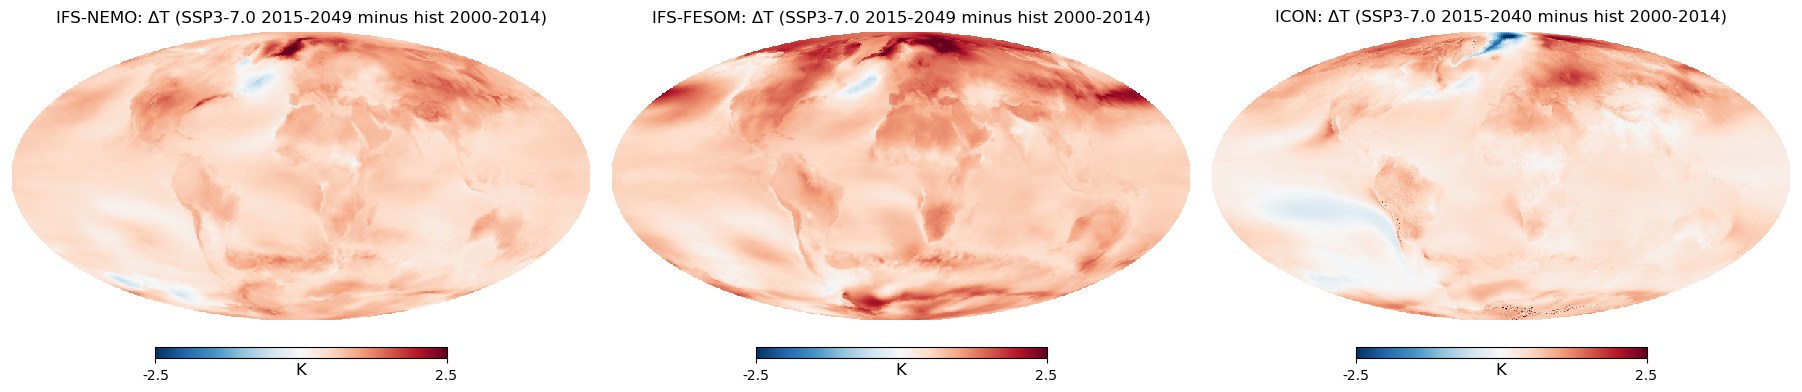

In [ ]:
# Plot climate change signal for each model
vmin = -2.5
vmax = 2.5

fig = plt.figure(figsize=(18, 5))
for i, model in enumerate(MODELS):
    scen_end = _MODEL_ENDYEAR_RELEASE[model]
    hp.mollview(
        diffs[model].values, nest=True, flip='geo',
        cmap='RdBu_r', min=vmin, max=vmax,
        title=f'{model}: \u0394T ({SCEN_EXPERIMENT} 2015-{scen_end}'
              f' minus {HIST_EXPERIMENT} {HIST_YEARS[0]}-{HIST_YEARS[-1]})',
        unit='K', sub=(1, len(MODELS), i + 1),
    )

In [ ]:
# Global mean temperature change per model
# (HEALPix pixels are equal-area, so a simple mean is area-weighted)
for model in MODELS:
    print(f'{model}: global mean \u0394T = {float(diffs[model].mean()):.2f} K')

IFS-NEMO: global mean ΔT = 0.57 K
IFS-FESOM: global mean ΔT = 0.74 K
ICON: global mean ΔT = 0.41 K


## How to extend this notebook for your analysis

- **Change variable**: set `PARAM` to another variable shortName (e.g. `'avg_tprate'` for total precipitation rate), update `PARAM_NAME`. Use [05_variable_lookup.ipynb](05_variable_lookup.ipynb) to search available variables by name or keyword.
- **Seasonal breakdown**: after computing `diffs`, you can group by month using `xarray.groupby('valid_time.season')`
- **Store data locally**: set `STORE_DATA = True` and adjust `DATA_DIR`; subsequent runs will then load from cache
- **Explore the data lazily**: [03_lazy_browse_portfolio.ipynb](03_lazy_browse_portfolio.ipynb) (monthly) and [04_lazy_browse_portfolio_hourly.ipynb](04_lazy_browse_portfolio_hourly.ipynb) (hourly) let you browse the full portfolio as xarray Datasets without bulk downloads